In [1]:
import pandas as pd

ps1 = pd.read_csv("../data/raw/hydraulic/PS1.txt", sep="\t", header=None)
print("PS1 shape:", ps1.shape)

ts1 = pd.read_csv("../data/raw/hydraulic/TS1.txt", sep="\t", header=None)
print("TS1 shape:", ts1.shape)

profile = pd.read_csv("../data/raw/hydraulic/profile.txt", sep="\t", header=None)
print("profile shape:", profile.shape)
print(profile.head())

PS1 shape: (2205, 6000)
TS1 shape: (2205, 60)
profile shape: (2205, 5)
   0    1  2    3  4
0  3  100  0  130  1
1  3  100  0  130  1
2  3  100  0  130  1
3  3  100  0  130  1
4  3  100  0  130  1


In [2]:
profile.columns = ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure", "stable_flag"]
print(profile["cooler_condition"].value_counts())
print()
print(profile.head())

cooler_condition
100    741
3      732
20     732
Name: count, dtype: int64

   cooler_condition  valve_condition  pump_leakage  accumulator_pressure  \
0                 3              100             0                   130   
1                 3              100             0                   130   
2                 3              100             0                   130   
3                 3              100             0                   130   
4                 3              100             0                   130   

   stable_flag  
0            1  
1            1  
2            1  
3            1  
4            1  


In [3]:
ce = pd.read_csv("../data/raw/hydraulic/CE.txt", sep="\t", header=None)
cp = pd.read_csv("../data/raw/hydraulic/CP.txt", sep="\t", header=None)

print("CE shape:", ce.shape)
print("CP shape:", cp.shape)

# Quick look: does CE (cooling efficiency) visibly differ across cooler condition classes?
# Use the mean of each cycle's 60 one-second readings as a first, simple summary
ce_mean_per_cycle = ce.mean(axis=1)

comparison = pd.DataFrame({
    "cooler_condition": profile["cooler_condition"],
    "CE_mean": ce_mean_per_cycle
})
print(comparison.groupby("cooler_condition")["CE_mean"].describe())

CE shape: (2205, 60)
CP shape: (2205, 60)
                  count       mean       std        min        25%        50%  \
cooler_condition                                                                
3                 732.0  19.572635  1.052965  17.555983  18.905904  19.631683   
20                732.0  27.201670  0.596833  22.752250  26.598746  27.381242   
100               741.0  46.930734  0.558261  35.708767  46.673850  46.935650   

                        75%        max  
cooler_condition                        
3                 20.081646  39.601350  
20                27.644733  28.290700  
100               47.229017  47.903667  


In [4]:
ts1 = pd.read_csv("../data/raw/hydraulic/TS1.txt", sep="\t", header=None)
ts2 = pd.read_csv("../data/raw/hydraulic/TS2.txt", sep="\t", header=None)

features_cooler = pd.DataFrame({
    "CE_mean": ce.mean(axis=1),
    "CE_std": ce.std(axis=1),
    "CP_mean": cp.mean(axis=1),
    "CP_std": cp.std(axis=1),
    "TS1_mean": ts1.mean(axis=1),
    "TS2_mean": ts2.mean(axis=1),
})

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = features_cooler
y = profile["cooler_condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 1.0
              precision    recall  f1-score   support

           3       1.00      1.00      1.00       147
          20       1.00      1.00      1.00       146
         100       1.00      1.00      1.00       148

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



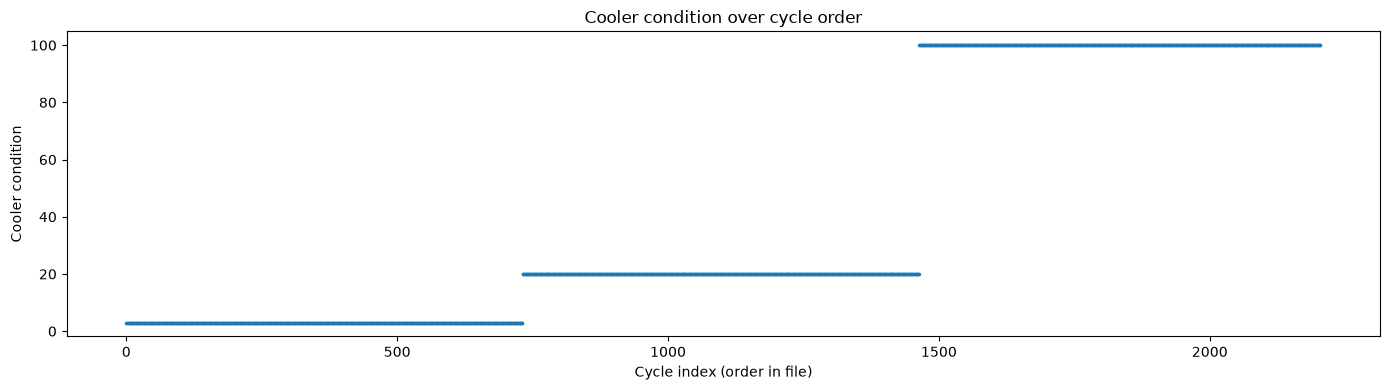

Number of contiguous blocks (label changes): 3


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(profile.index, profile["cooler_condition"], marker='.', linestyle='none', markersize=3)
plt.xlabel("Cycle index (order in file)")
plt.ylabel("Cooler condition")
plt.title("Cooler condition over cycle order")
plt.tight_layout()
plt.show()

# Also check: how many separate contiguous "runs" of each label exist?
changes = (profile["cooler_condition"] != profile["cooler_condition"].shift()).sum()
print(f"Number of contiguous blocks (label changes): {changes}")

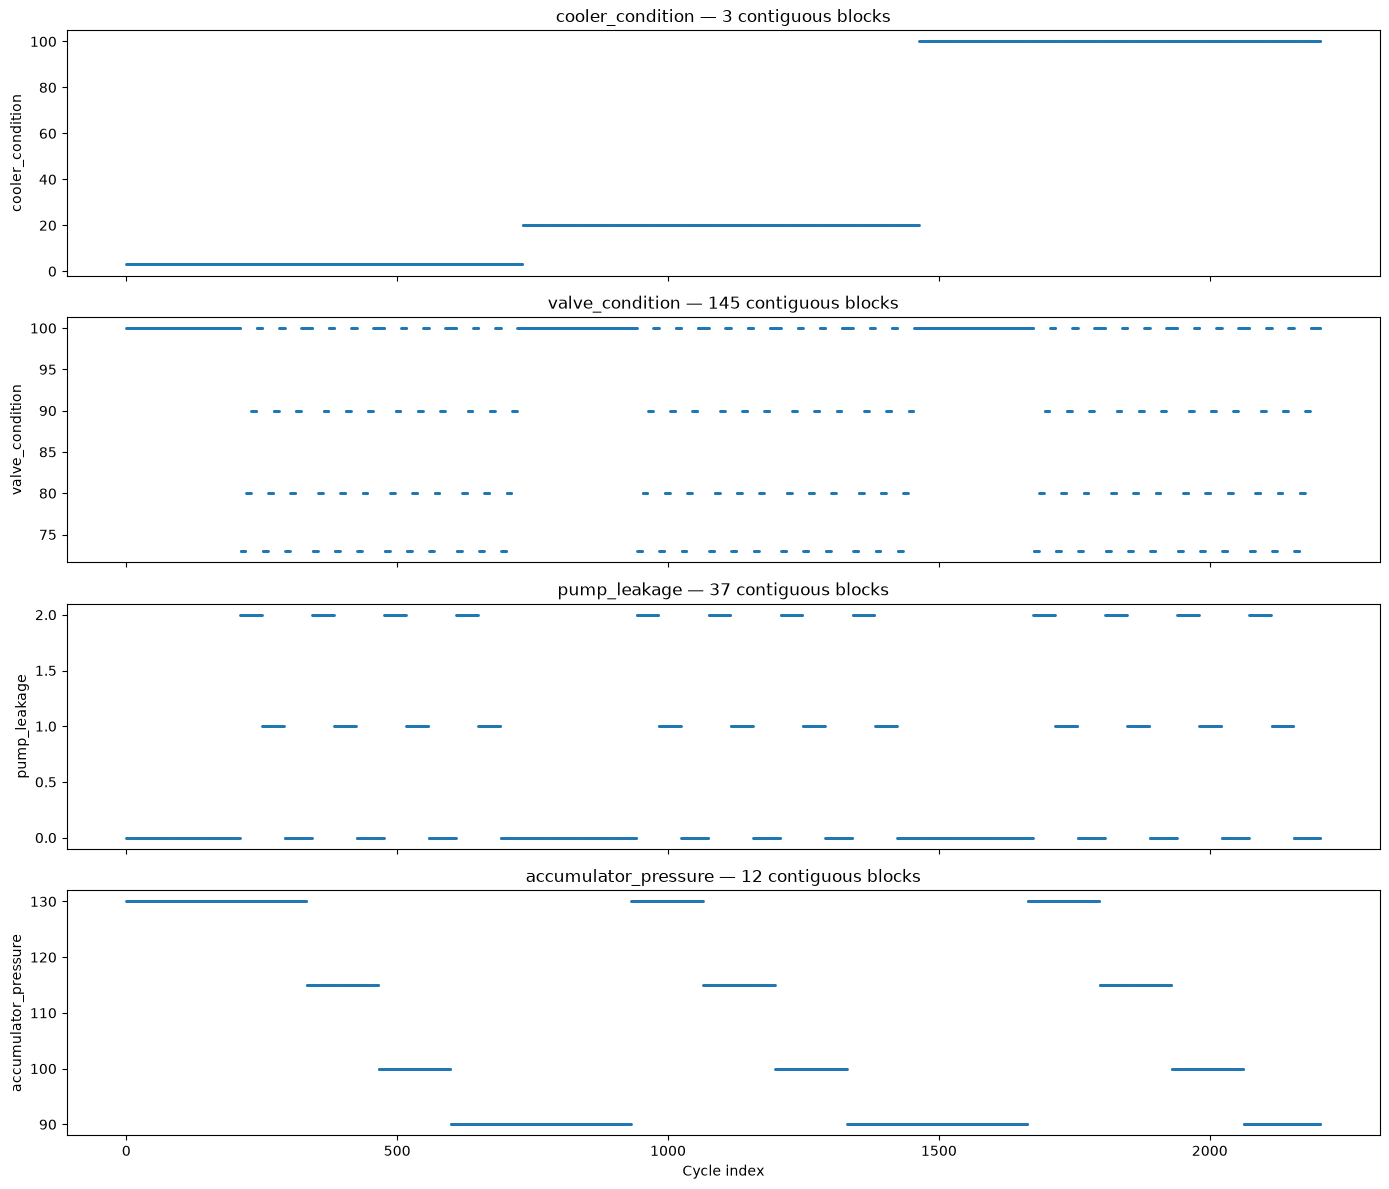

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"]):
    ax.plot(profile.index, profile[col], marker='.', linestyle='none', markersize=2)
    ax.set_ylabel(col)
    changes = (profile[col] != profile[col].shift()).sum()
    ax.set_title(f"{col} — {changes} contiguous blocks")
axes[-1].set_xlabel("Cycle index")
plt.tight_layout()
plt.show()

In [7]:
# Identify contiguous blocks for cooler_condition
profile["block_id"] = (profile["cooler_condition"] != profile["cooler_condition"].shift()).cumsum()

print(profile.groupby("block_id")["cooler_condition"].agg(["first", "count"]))

# Time-based split: first 80% of each block -> train, last 20% -> test
train_idx = []
test_idx = []

for block_id, group in profile.groupby("block_id"):
    n = len(group)
    split_point = int(n * 0.8)
    train_idx.extend(group.index[:split_point])
    test_idx.extend(group.index[split_point:])

print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")

# Rebuild features_cooler with the same features as before, then split properly
X_train_time = features_cooler.loc[train_idx]
X_test_time = features_cooler.loc[test_idx]
y_train_time = profile.loc[train_idx, "cooler_condition"]
y_test_time = profile.loc[test_idx, "cooler_condition"]

clf_time = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf_time.fit(X_train_time, y_train_time)
preds_time = clf_time.predict(X_test_time)

print("Time-based split accuracy:", accuracy_score(y_test_time, preds_time))
print(classification_report(y_test_time, preds_time))

          first  count
block_id              
1             3    732
2            20    732
3           100    741
Train size: 1762, Test size: 443
Time-based split accuracy: 1.0
              precision    recall  f1-score   support

           3       1.00      1.00      1.00       147
          20       1.00      1.00      1.00       147
         100       1.00      1.00      1.00       149

    accuracy                           1.00       443
   macro avg       1.00      1.00      1.00       443
weighted avg       1.00      1.00      1.00       443



In [8]:
importances_cooler = pd.DataFrame({
    "feature": features_cooler.columns,
    "importance": clf_time.feature_importances_
}).sort_values("importance", ascending=False)
print(importances_cooler)

    feature  importance
0   CE_mean    0.388827
2   CP_mean    0.266166
4  TS1_mean    0.195052
5  TS2_mean    0.143738
3    CP_std    0.005131
1    CE_std    0.001086


In [9]:
# Load the pressure and flow sensors
ps_sensors = {}
for i in range(1, 7):
    ps_sensors[f"PS{i}"] = pd.read_csv(f"../data/raw/hydraulic/PS{i}.txt", sep="\t", header=None)

fs1 = pd.read_csv("../data/raw/hydraulic/FS1.txt", sep="\t", header=None)
fs2 = pd.read_csv("../data/raw/hydraulic/FS2.txt", sep="\t", header=None)
eps1 = pd.read_csv("../data/raw/hydraulic/EPS1.txt", sep="\t", header=None)

# Build features: mean, std, and range (max-min) per cycle - range specifically to capture "how much did it swing", relevant to switching behavior
features_valve = pd.DataFrame()
for name, df in {**ps_sensors, "FS1": fs1, "FS2": fs2, "EPS1": eps1}.items():
    features_valve[f"{name}_mean"] = df.mean(axis=1)
    features_valve[f"{name}_std"] = df.std(axis=1)
    features_valve[f"{name}_range"] = df.max(axis=1) - df.min(axis=1)

print(features_valve.shape)
print(features_valve.head())

(2205, 27)
     PS1_mean    PS1_std  PS1_range    PS2_mean    PS2_std  PS2_range  \
0  160.673492  13.939309      45.68  109.466914  47.114508     156.99   
1  160.603320  14.118967      45.74  109.354890  47.045611     157.56   
2  160.347720  14.192619      46.04  109.158845  46.992060     156.97   
3  160.188088  14.227803      46.20  109.064807  46.972221     156.44   
4  160.000472  14.276434      46.46  108.931434  46.874946     158.13   

   PS3_mean   PS3_std  PS3_range  PS4_mean  ...  PS6_range  FS1_mean  \
0  1.991475  0.945705     10.039       0.0  ...      0.319  6.709815   
1  1.976234  0.941967      9.992       0.0  ...      0.183  6.715315   
2  1.972224  0.943501     10.914       0.0  ...      0.188  6.718522   
3  1.946575  0.935534     10.297       0.0  ...      0.174  6.720565   
4  1.922707  0.930335     11.102       0.0  ...      0.147  6.690308   

    FS1_std  FS1_range   FS2_mean   FS2_std  FS2_range    EPS1_mean  \
0  3.015428     18.710  10.304592  0.091772   

In [10]:
print("PS4 overall stats:", ps_sensors["PS4"].values.flatten().min(), ps_sensors["PS4"].values.flatten().max())
print("PS4_mean std across all cycles:", features_valve["PS4_mean"].std())

PS4 overall stats: 0.0 10.266
PS4_mean std across all cycles: 4.2793546757965455


In [11]:
# Build blocks for valve specifically
profile["valve_block_id"] = (profile["valve_condition"] != profile["valve_condition"].shift()).cumsum()
print(f"Number of valve blocks: {profile['valve_block_id'].nunique()}")
print(profile.groupby("valve_condition")["valve_block_id"].nunique())  # blocks per class - checking balance

# Time-based split: first 80% of each block -> train, last 20% -> test
train_idx_valve = []
test_idx_valve = []
for block_id, group in profile.groupby("valve_block_id"):
    n = len(group)
    split_point = max(1, int(n * 0.8))
    train_idx_valve.extend(group.index[:split_point])
    test_idx_valve.extend(group.index[split_point:])

print(f"Train: {len(train_idx_valve)}, Test: {len(test_idx_valve)}")

X_train_valve = features_valve.loc[train_idx_valve].drop(columns=["PS4_mean", "PS4_std", "PS4_range"])
X_test_valve = features_valve.loc[test_idx_valve].drop(columns=["PS4_mean", "PS4_std", "PS4_range"])
y_train_valve = profile.loc[train_idx_valve, "valve_condition"]
y_test_valve = profile.loc[test_idx_valve, "valve_condition"]

clf_valve = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
clf_valve.fit(X_train_valve, y_train_valve)
preds_valve = clf_valve.predict(X_test_valve)

print("Valve accuracy (time-based block split):", accuracy_score(y_test_valve, preds_valve))
print(classification_report(y_test_valve, preds_valve))

Number of valve blocks: 145
valve_condition
73     36
80     36
90     36
100    37
Name: valve_block_id, dtype: int64
Train: 1735, Test: 470
Valve accuracy (time-based block split): 0.9595744680851064
              precision    recall  f1-score   support

          73       0.99      0.99      0.99        72
          80       0.99      0.97      0.98        72
          90       0.97      0.82      0.89        72
         100       0.94      0.99      0.97       254

    accuracy                           0.96       470
   macro avg       0.97      0.94      0.95       470
weighted avg       0.96      0.96      0.96       470



In [12]:
X_train_valve = features_valve.loc[train_idx_valve]  # PS4 columns included now
X_test_valve = features_valve.loc[test_idx_valve]

clf_valve2 = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
clf_valve2.fit(X_train_valve, y_train_valve)
preds_valve2 = clf_valve2.predict(X_test_valve)

print("Valve accuracy WITH PS4:", accuracy_score(y_test_valve, preds_valve2))
print(classification_report(y_test_valve, preds_valve2))

Valve accuracy WITH PS4: 0.9574468085106383
              precision    recall  f1-score   support

          73       1.00      0.99      0.99        72
          80       0.97      0.97      0.97        72
          90       0.97      0.81      0.88        72
         100       0.94      0.99      0.96       254

    accuracy                           0.96       470
   macro avg       0.97      0.94      0.95       470
weighted avg       0.96      0.96      0.96       470



In [13]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_valve, preds_valve2, labels=[73, 80, 90, 100])
print(pd.DataFrame(cm, index=[73, 80, 90, 100], columns=[73, 80, 90, 100]))

     73   80   90   100
73    71    1    0    0
80     0   70    0    2
90     0    0   58   14
100    0    1    2  251
